1. Import der benötigten Bibliotheken
Der Code beginnt mit dem Import von drei wichtigen Python‑Bibliotheken:

pandas: zum Laden, Verarbeiten und Analysieren von Daten

matplotlib.pyplot und seaborn: zur Erstellung von Diagrammen und Visualisierungen

Diese Bibliotheken sind Standardwerkzeuge für Datenanalyse und Exploratory Data Analysis (EDA).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

2. Laden des Datensatzes
Hier wird eine CSV‑Datei mit dem Namen GA4_Ecommer.csv aus dem lokalen Verzeichnis geladen.
Die Funktion pd.read_csv() liest die Datei ein und speichert sie als DataFrame namens df.

In [2]:
df = pd.read_csv(r'C:\\Users\\shiva\\OneDrive\\Desktop\\weiter bildung\\projekt\\ki-marketing-personalisierung-main\\data\\processed\\GA4_Ecommer.csv')


3. Erste Ansicht der Daten
df.head() zeigt die ersten fünf Zeilen des Datensatzes.
Damit erhält man einen schnellen Überblick über:

Spaltennamen

Datentypen

Beispielwerte

In [3]:
print(df.head())

   event_date  event_timestamp       event_name  user_pseudo_id platform  \
0    20210131     1.612070e+15        page_view     1026454.427      WEB   
1    20210131     1.612070e+15           scroll     1026454.427      WEB   
2    20210131     1.612070e+15        page_view     1026454.427      WEB   
3    20210131     1.612070e+15  user_engagement     1026454.427      WEB   
4    20210131     1.612070e+15    session_start     1026454.427      WEB   

  device_category        country  
0          mobile  United States  
1          mobile  United States  
2          mobile  United States  
3          mobile  United States  
4          mobile  United States  


4. Informationen über den DataFrame

df.info() liefert eine strukturierte Zusammenfassung des DataFrames:

Anzahl der Zeilen und Spalten

Datentypen jeder Spalte

Anzahl der fehlenden Werte

Speicherverbrauch

Diese Informationen sind wichtig, um die Datenqualität einzuschätzen.

In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26489 entries, 0 to 26488
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   event_date       26489 non-null  int64  
 1   event_timestamp  26489 non-null  float64
 2   event_name       26489 non-null  object 
 3   user_pseudo_id   26489 non-null  float64
 4   platform         26489 non-null  object 
 5   device_category  26489 non-null  object 
 6   country          26489 non-null  object 
dtypes: float64(2), int64(1), object(4)
memory usage: 1.4+ MB
None


5. Überprüfung auf fehlende Werte

Dieser Befehl zählt, wie viele NaN‑Werte (fehlende Daten) in jeder Spalte vorkommen.
Das ist ein zentraler Schritt vor der Datenbereinigung und EDA.

In [5]:
df.isna().sum()

event_date         0
event_timestamp    0
event_name         0
user_pseudo_id     0
platform           0
device_category    0
country            0
dtype: int64

1. Umwandlung der Nutzer‑ID in einen String

Hier wird die Spalte user_pseudo_id in den Datentyp String umgewandelt.
Das ist wichtig, weil Nutzer‑IDs keine numerischen Werte darstellen, sondern eindeutige Identifikatoren, die nicht mathematisch verarbeitet werden sollen.
Durch die Umwandlung wird sichergestellt, dass Python die IDs korrekt als Text behandelt.

2. Konvertierung des Ereignis‑Zeitstempels

Die Spalte event_timestamp enthält Zeitstempel im Mikrosekunden‑Format.
Mit pd.to_datetime(..., unit='us') wird der Zeitstempel in ein lesbares Datum‑Zeit‑Format umgewandelt.
Dadurch können später zeitbasierte Analysen durchgeführt werden, z. B.:

Tages‑ oder Wochenanalysen

Session‑Analysen

Zeitreihenvisualisierungen

3. Konvertierung des Ereignisdatums

Die Spalte event_date liegt im Format YYYYMMDD vor (z. B. 20240115).
Mit diesem Befehl wird sie in ein echtes Datumsformat umgewandelt.
Das erleichtert:

Gruppierungen nach Datum

Filterung nach Zeiträumen

Erstellung von Zeitdiagrammen

4. Häufigkeit der Nutzer‑IDs anzeigen

Dieser Befehl zeigt die fünf am häufigsten vorkommenden Nutzer‑IDs.
Das ist nützlich, um zu erkennen:

welche Nutzer besonders aktiv sind

ob es ungewöhnlich viele Wiederholungen gibt

ob Tracking‑Daten korrekt erfasst wurden

5. Anzeige der ersten Datumswerte

Hier werden die ersten fünf Werte der Spalte event_date ausgegeben.
Damit überprüft man, ob die Datumsumwandlung korrekt funktioniert hat.

In [16]:
df['user_pseudo_id'] = df['user_pseudo_id'].astype(str)
df['event_timestamp'] = pd.to_datetime(df['event_timestamp'], unit='us')
df['event_date'] = pd.to_datetime(df['event_date'], format='%Y%m%d')
print(df['user_pseudo_id'].value_counts().head())
print(df['event_date'].head())

user_pseudo_id
22223267.96     247
18260385.74     227
84278607.38     185
6801821.537     183
9021020865.0    178
Name: count, dtype: int64
0   2021-01-31
1   2021-01-31
2   2021-01-31
3   2021-01-31
4   2021-01-31
Name: event_date, dtype: datetime64[ns]


Anzeige der ersten 100 Werte der Spalte event_timestamp

Dieser Befehl gibt die ersten 100 Einträge der Spalte event_timestamp aus dem DataFrame zurück.

Nachdem die Spalte zuvor mit

df['event_timestamp'] = pd.to_datetime(df['event_timestamp'], unit='us')

in ein lesbares Datums‑ und Zeitformat umgewandelt wurde, zeigt dieser Befehl nun:

die chronologische Reihenfolge der ersten erfassten Ereignisse

das genaue Datum und die Uhrzeit jedes Events

ob die Konvertierung korrekt funktioniert hat

ob die Daten vollständig und logisch erscheinen

Dies ist ein typischer Schritt in der Exploratory Data Analysis (EDA), um sicherzustellen, dass Zeitstempel richtig interpretiert wurden und keine unerwarteten Werte enthalten sind.

In [17]:
df['event_timestamp'].head(100)

0    2021-01-31 05:05:10.766593
1    2021-01-31 05:05:29.243877
2    2021-01-31 05:05:15.781635
3    2021-01-31 05:05:30.073506
4    2021-01-31 05:05:10.766593
                ...            
95   2021-01-31 04:19:21.108552
96   2021-01-31 04:19:21.108552
97   2021-01-31 04:19:53.880113
98   2021-01-31 04:19:21.108552
99   2021-01-31 05:13:20.000000
Name: event_timestamp, Length: 100, dtype: datetime64[ns]

1. Statistische Übersicht über alle Spalten
Dieser Befehl erzeugt eine umfassende statistische Zusammenfassung des gesamten DataFrames.
Durch include='all' werden alle Spaltentypen berücksichtigt, nicht nur numerische Werte.

Die Ausgabe enthält je nach Spaltentyp:

Numerische Spalten:

count (Anzahl der Werte)

mean (Durchschnitt)

std (Standardabweichung)

min, max

Quartile (25%, 50%, 75%)

Kategorische/Objekt‑Spalten:

count (Anzahl der nicht‑fehlenden Werte)

unique (Anzahl verschiedener Werte)

top (häufigster Wert)

freq (Häufigkeit des häufigsten Wertes)

Diese Übersicht ist ein zentraler Schritt der Exploratory Data Analysis (EDA), um:

Datenverteilungen zu verstehen

Ausreißer zu erkennen

Häufigkeiten und Muster zu identifizieren

Datenqualität einzuschätzen

In [6]:
df.describe(include='all')

,event_date,event_timestamp,event_name,user_pseudo_id,platform,device_category,country
count,26489.0,2.648900e+04,26489,2.648900e+04,26489,26489,26489
unique,NaN,NaN,16,NaN,1,3,88
top,NaN,NaN,page_view,NaN,WEB,desktop,United States
freq,NaN,NaN,9498,NaN,26489,15239,11362
mean,20210131.0,1.612095e+15,NaN,3.071288e+08,NaN,NaN,NaN
std,0.0,2.527896e+10,NaN,1.349818e+09,NaN,NaN,NaN
min,20210131.0,1.612050e+15,NaN,1.026454e+06,NaN,NaN,NaN
25%,20210131.0,1.612073e+15,NaN,6.177527e+06,NaN,NaN,NaN
50%,20210131.0,1.612095e+15,NaN,2.220593e+07,NaN,NaN,NaN
75%,20210131.0,1.612117e+15,NaN,6.331926e+07,NaN,NaN,NaN


2. Struktur und Datentypen des DataFrames

Dieser Befehl zeigt eine strukturierte Zusammenfassung des DataFrames:

Anzahl der Zeilen und Spalten

Spaltennamen

Datentypen (z. B. int64, float64, object, datetime64)

Anzahl der nicht‑fehlenden Werte pro Spalte

Speicherverbrauch

df.info() ist besonders hilfreich, um:

fehlende Werte zu erkennen

Datentypen für spätere Analysen zu überprüfen

sicherzustellen, dass Datums‑ und Zeitspalten korrekt konvertiert wurden

die allgemeine Datenqualität einzuschätzen

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26489 entries, 0 to 26488
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   event_date       26489 non-null  int64  
 1   event_timestamp  26489 non-null  float64
 2   event_name       26489 non-null  object 
 3   user_pseudo_id   26489 non-null  float64
 4   platform         26489 non-null  object 
 5   device_category  26489 non-null  object 
 6   country          26489 non-null  object 
dtypes: float64(2), int64(1), object(4)
memory usage: 1.4+ MB


Der Code erstellt ein Balkendiagramm, das zeigt, wie oft jedes Event im Datensatz vorkommt.
Zuerst werden mit value_counts() die Häufigkeiten der verschiedenen Event‑Namen gezählt. Anschließend wird mit plot(kind='bar') ein Balkendiagramm erzeugt, das diese Verteilung visuell darstellt.
Der Titel sowie die Achsenbeschriftungen sorgen dafür, dass das Diagramm klar und verständlich interpretiert werden kann.
Mit plt.show() wird die Grafik schließlich angezeigt.

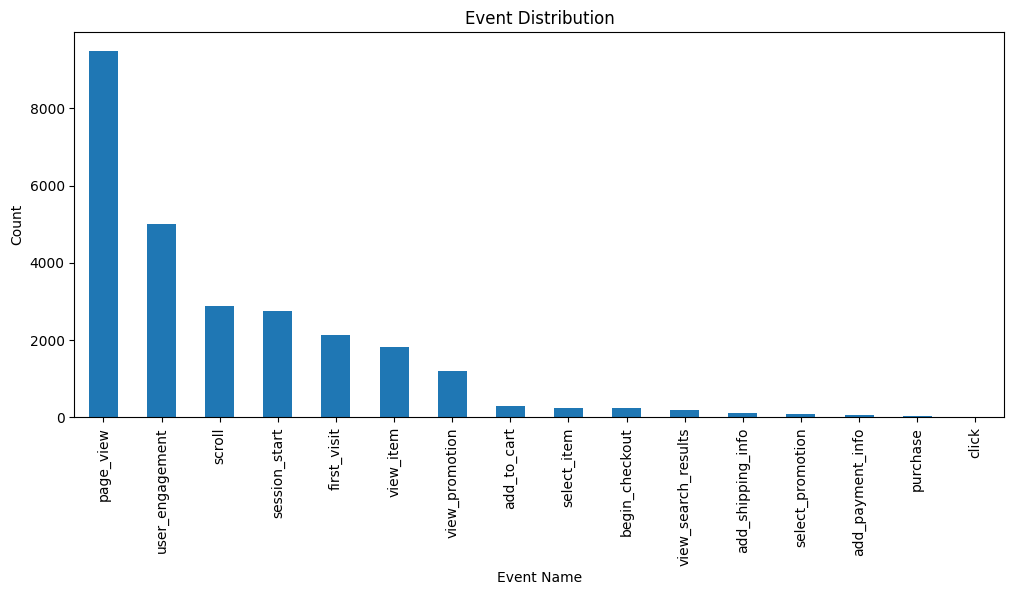

In [19]:
df['event_name'].value_counts().plot(kind='bar', figsize=(12,5))
plt.title("Event Distribution")
plt.xlabel("Event Name")
plt.ylabel("Count")
plt.show()


Der Code identifiziert die 20 aktivsten Nutzer im Datensatz und visualisiert ihre Aktivität in einem Balkendiagramm.
Zuerst wird mit value_counts().head(20) gezählt, welche Nutzer‑IDs die meisten Events erzeugt haben. Anschließend wird mit plot(kind='bar') ein Balkendiagramm erstellt, das zeigt, wie viele Events jeder dieser Top‑User ausgelöst hat.
Der Titel und die Achsenbeschriftungen sorgen dafür, dass die Grafik klar verständlich ist.
Diese Visualisierung hilft dabei, besonders aktive oder auffällige Nutzer zu erkennen und das allgemeine Nutzungsverhalten besser zu verstehen.

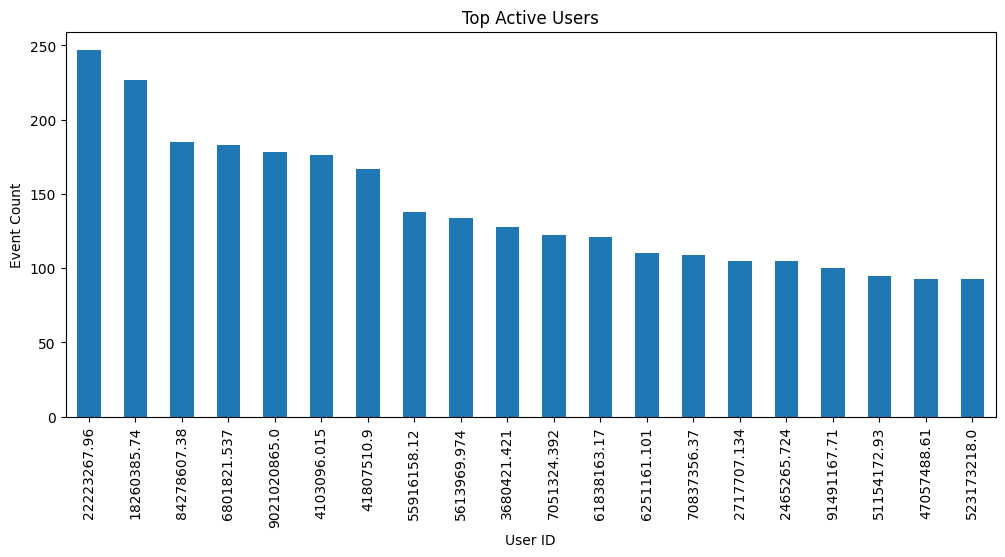

In [20]:
df['user_pseudo_id'].value_counts().head(20).plot(kind='bar', figsize=(12,5))
plt.title("Top Active Users")
plt.xlabel("User ID")
plt.ylabel("Event Count")
plt.show()


Der Code analysiert, zu welchen Tageszeiten die meisten Events stattfinden.
Zuerst wird aus dem Zeitstempel (event_timestamp) die Stunde des Tages extrahiert und in einer neuen Spalte namens hour gespeichert.
Anschließend werden die Event‑Häufigkeiten pro Stunde gezählt, nach Stunden sortiert und als Liniendiagramm dargestellt.
Das Diagramm zeigt klar, zu welchen Uhrzeiten die Nutzer am aktivsten sind.
Mit Titel, Achsenbeschriftungen und einem Raster wird die Visualisierung übersichtlich und leicht interpretierbar.

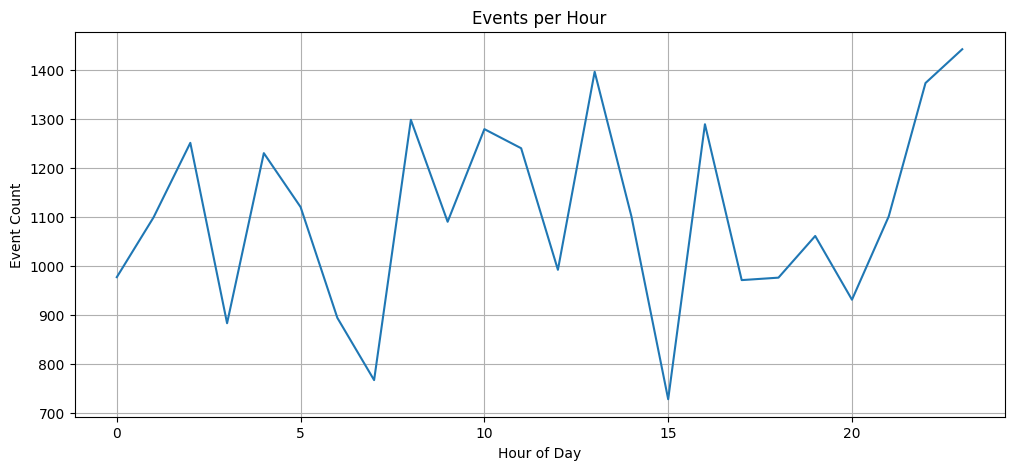

In [21]:
df['hour'] = df['event_timestamp'].dt.hour

df['hour'].value_counts().sort_index().plot(kind='line', figsize=(12,5))
plt.title("Events per Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Event Count")
plt.grid(True)
plt.show()


Der Code visualisiert die Verteilung der Gerätekategorien, über die die Nutzer auf die Website oder App zugreifen.
Mit value_counts() werden die Häufigkeiten der verschiedenen device_category‑Werte gezählt. Anschließend wird ein Kreisdiagramm (Pie Chart) erstellt, das zeigt, welcher Anteil der Events von Desktop‑, Mobile‑ oder Tablet‑Geräten stammt.
Die Prozentangaben (autopct='%1.1f%%') machen die Verteilung leicht verständlich, und der Titel sorgt für eine klare Einordnung der Grafik.
Diese Darstellung hilft dabei zu erkennen, welche Gerätetypen für die Nutzung am wichtigsten sind.

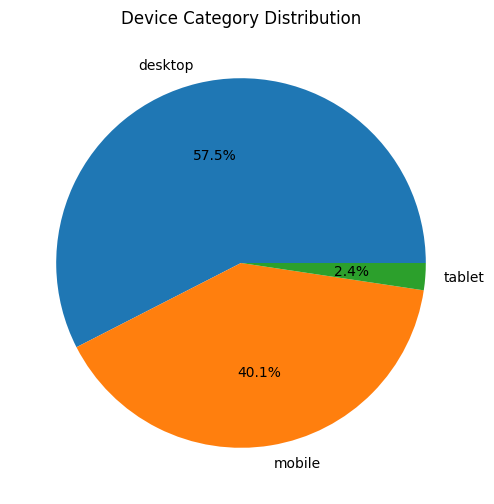

In [22]:
df['device_category'].value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(6,6))
plt.title("Device Category Distribution")
plt.ylabel("")
plt.show()


Der Code zeigt die Top 10 Länder mit den meisten Events im Datensatz.
Zuerst werden mit value_counts().head(10) die zehn Länder ermittelt, aus denen die meisten Nutzeraktivitäten stammen. Anschließend wird ein Balkendiagramm erstellt, das die Event‑Häufigkeit pro Land visualisiert.
Der Titel und die Achsenbeschriftungen machen die Darstellung klar und leicht verständlich.
Diese Visualisierung hilft dabei zu erkennen, aus welchen Ländern die meisten Interaktionen kommen und welche Regionen für das Nutzerverhalten besonders relevant sind.

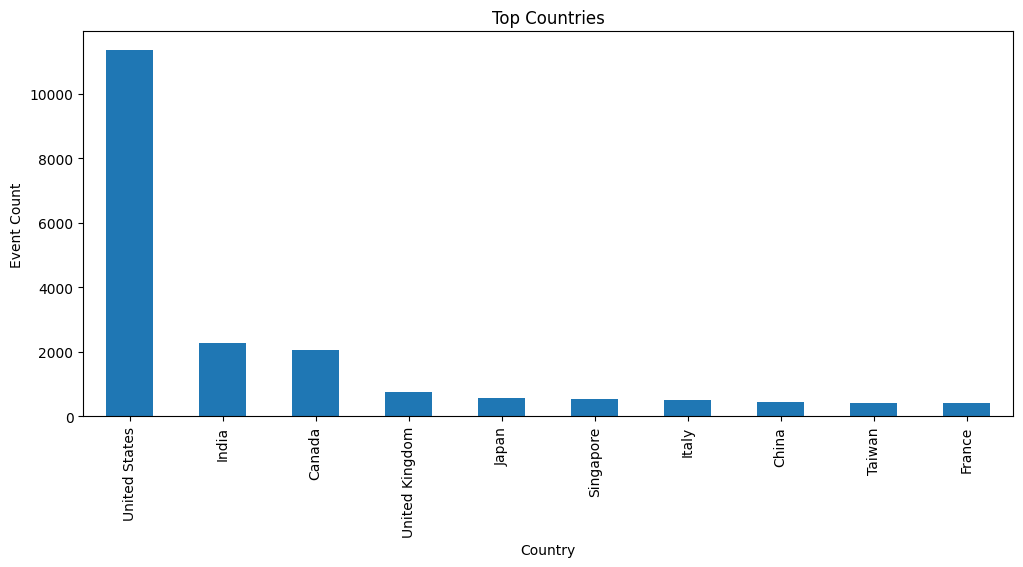

In [23]:
df['country'].value_counts().head(10).plot(kind='bar', figsize=(12,5))
plt.title("Top Countries")
plt.xlabel("Country")
plt.ylabel("Event Count")
plt.show()


Der Code erstellt eine Pivot-Tabelle, die zeigt, wie viele Events jeder Gerätetyp (device_category) für jede Event‑Art (event_name) erzeugt hat.
Mit aggfunc='size' wird die Anzahl der Ereignisse gezählt, und fill_value=0 sorgt dafür, dass fehlende Kombinationen als 0 dargestellt werden.
Das Ergebnis ist eine übersichtliche Matrix, die auf einen Blick erkennen lässt, welche Geräte (z. B. mobile, desktop, tablet) welche Events am häufigsten auslösen.
Diese Darstellung ist besonders nützlich, um Unterschiede im Nutzerverhalten zwischen verschiedenen Gerätetypen zu analysieren.

In [25]:
pd.pivot_table(
    df,
    index='device_category',
    columns='event_name',
    aggfunc='size',
    fill_value=0
)


event_name,add_payment_info,add_shipping_info,add_to_cart,begin_checkout,click,first_visit,page_view,purchase,scroll,select_item,select_promotion,session_start,user_engagement,view_item,view_promotion,view_search_results
device_category,,,,,,,,,,,,,,,,
desktop,34,55,168,129,1,1220,5434,11,1645,130,40,1576,2877,1133,686,100
mobile,18,39,125,91,2,849,3843,7,1153,106,30,1113,2006,673,474,95
tablet,1,6,2,14,0,58,221,1,72,1,1,71,122,23,30,3
